In [1]:
import tensorflow as tf
print(tf.__version__)

/Users/srishtialanse/tfenv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


2.20.0


In [2]:
import tensorflow as tf
print("TF version:", tf.__version__)
print("GPUs:", tf.config.list_physical_devices('GPU'))

TF version: 2.20.0
GPUs: []


In [3]:
# import os
# import numpy as np
# import matplotlib.pyplot as plt
# import tensorflow as tf
# from tensorflow import keras
# from tensorflow.keras import layers
# from sklearn.model_selection import train_test_split
# os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

# import warnings
# warnings.filterwarnings('ignore')


import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split

print("TF version:", tf.__version__)
print("GPUs:", tf.config.list_physical_devices("GPU"))

TF version: 2.20.0
GPUs: []


In [4]:

from tensorflow.keras.preprocessing import image
import numpy as np
import os

IMG_SIZE = 224

data = []
labels = []

path = "data"

for category in ["no", "yes"]:
    folder = os.path.join(path, category)
    images = os.listdir(folder)

    print(f"{category.upper()} images: {len(images)}")  # ✅ COUNT

    label = 0 if category == "no" else 1

    for img in images:
        img_path = os.path.join(folder, img)
        try:
            img = image.load_img(img_path, target_size=(IMG_SIZE, IMG_SIZE))
            img_array = image.img_to_array(img)

            data.append(img_array)
            labels.append(label)

        except:
            print("Skipped:", img_path)

data = np.array(data, dtype='float32') / 255.0
labels = np.array(labels)

print("Dataset loaded:", data.shape)

NO images: 572
Skipped: data/no/.DS_Store
YES images: 492
Skipped: data/yes/.DS_Store
Dataset loaded: (1062, 224, 224, 3)


No Tumor: 571
Yes Tumor: 491


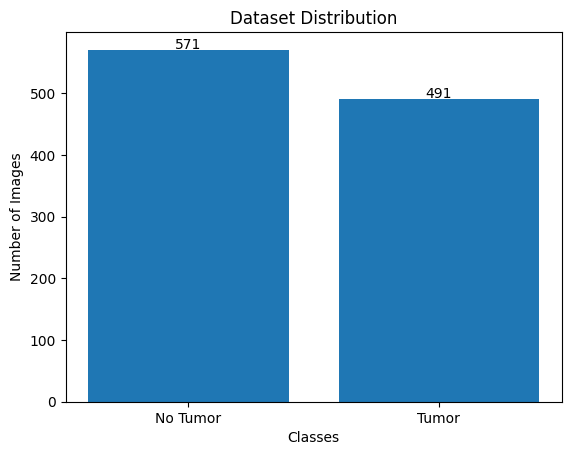

In [5]:
no_count = np.sum(labels == 0)
yes_count = np.sum(labels == 1)

print(f"No Tumor: {no_count}")
print(f"Yes Tumor: {yes_count}")


counts = [no_count, yes_count]
labels_names = ["No Tumor", "Tumor"]

plt.figure()
plt.bar(labels_names, counts)

plt.title("Dataset Distribution")
plt.xlabel("Classes")
plt.ylabel("Number of Images")

for i, v in enumerate(counts):
    plt.text(i, v + 2, str(v), ha='center')

plt.show()

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    data, labels, test_size=0.2, random_state=42
)

In [7]:
def build_cnn():
    model = keras.Sequential([
        layers.Conv2D(32, (3,3), activation='relu', input_shape=(224,224,3)),
        layers.MaxPooling2D(),

        layers.Conv2D(64, (3,3), activation='relu'),
        layers.MaxPooling2D(),

        layers.Conv2D(128, (3,3), activation='relu'),
        layers.MaxPooling2D(),

        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(1, activation='sigmoid')
    ])

    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model

In [8]:
def build_mobilenet():
    base = keras.applications.MobileNetV2(
        input_shape=(224,224,3),
        include_top=False,
        weights='imagenet'
    )
    base.trainable = False

    x = layers.GlobalAveragePooling2D()(base.output)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.5)(x)
    output = layers.Dense(1, activation='sigmoid')(x)

    model = keras.Model(inputs=base.input, outputs=output)

    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model

In [9]:
def build_resnet():
    base = keras.applications.ResNet50(
        input_shape=(224,224,3),
        include_top=False,
        weights='imagenet'
    )
    base.trainable = False

    x = layers.GlobalAveragePooling2D()(base.output)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.5)(x)
    output = layers.Dense(1, activation='sigmoid')(x)

    model = keras.Model(inputs=base.input, outputs=output)

    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model

In [10]:
models = {
    "CNN": build_cnn(),
    "MobileNet": build_mobilenet(),
    "ResNet": build_resnet()
}

history = {}
accuracies = {}
trained_models = {}

for name, model in models.items():
    print(f"\nTraining {name}...\n")

    h = model.fit(
    X_train, y_train,
    epochs=10,
    validation_data=(X_test, y_test),
    batch_size=16
    )
    loss, acc = model.evaluate(X_test, y_test)
    
    history[name] = h   

    accuracies[name] = acc        
    trained_models[name] = model    

    print(f"{name} Accuracy: {acc*100:.2f}%")

/Users/srishtialanse/tfenv/lib/python3.9/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



Training CNN...

Epoch 1/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 9s 156ms/step - accuracy: 0.5668 - loss: 0.8267 - val_accuracy: 0.7042 - val_loss: 0.6038
Epoch 2/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 9s 164ms/step - accuracy: 0.7220 - loss: 0.5646 - val_accuracy: 0.7371 - val_loss: 0.5345
Epoch 3/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 9s 167ms/step - accuracy: 0.7930 - loss: 0.4882 - val_accuracy: 0.7840 - val_loss: 0.4784
Epoch 4/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 9s 168ms/step - accuracy: 0.8369 - loss: 0.3464 - val_accuracy: 0.8545 - val_loss: 0.3538
Epoch 5/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 9s 170ms/step - accuracy: 0.8955 - loss: 0.2664 - val_accuracy: 0.8873 - val_loss: 0.3225
Epoch 6/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 9s 172ms/step - accuracy: 0.9364 - loss: 0.1542 - val_accuracy: 0.8826 - val_loss: 0.3754
Epoch 7/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 9s 175ms/step - accuracy: 0.9501 - loss: 0.1401 - val_accuracy: 0.8967 - val_loss: 0.4111
Epoch 8/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 10s 181ms/step - accuracy: 0.9568 - loss: 0.1007

7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 98ms/step


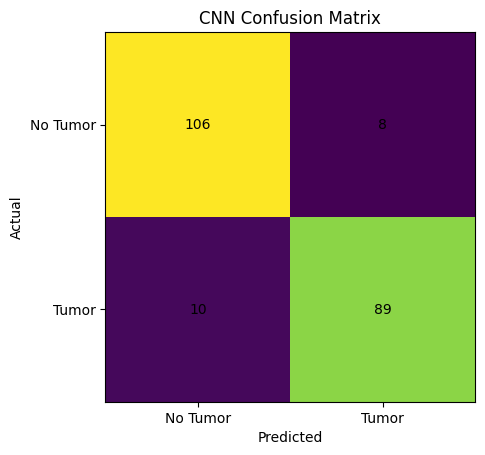

7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 174ms/step


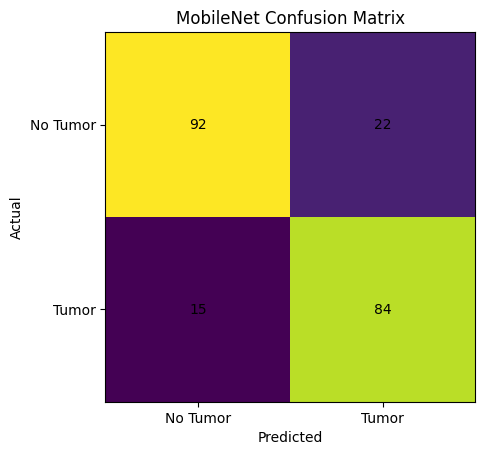

7/7 ━━━━━━━━━━━━━━━━━━━━ 6s 793ms/step


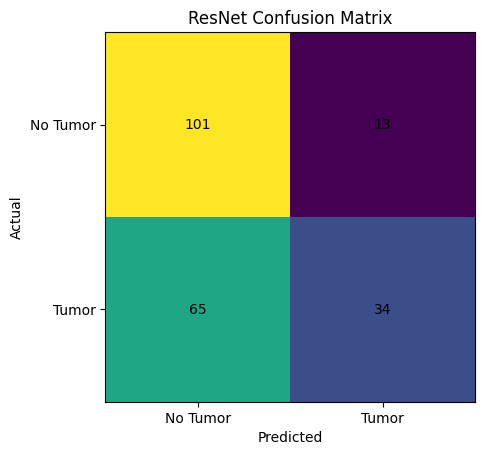

In [11]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

def plot_confusion_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)

    plt.figure()
    plt.imshow(cm)
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")

    # labels
    classes = ["No Tumor", "Tumor"]
    plt.xticks([0,1], classes)
    plt.yticks([0,1], classes)

    # numbers inside boxes
    for i in range(2):
        for j in range(2):
            plt.text(j, i, cm[i, j], ha='center', va='center')

    plt.show()


# 🔁 Loop through all models
for name, model in models.items():
    preds = model.predict(X_test)
    preds = (preds > 0.5).astype(int).flatten()

    plot_confusion_matrix(y_test, preds, f"{name} Confusion Matrix")

In [12]:
best_model_name = max(accuracies, key=accuracies.get)
best_model = models[best_model_name]

print("Best Model:", best_model_name)

best_model.save("best_brain_tumor_model.h5")

Best Model: CNN


In [13]:
model_names = list(accuracies.keys())
acc_values = list(accuracies.values())

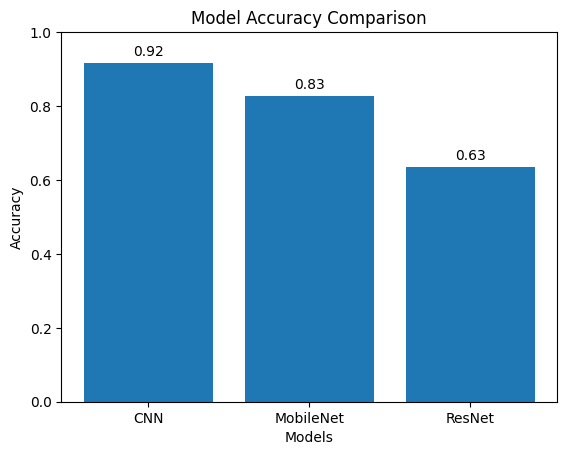

In [14]:
import matplotlib.pyplot as plt

plt.figure()
plt.bar(model_names, acc_values)

plt.title("Model Accuracy Comparison")
plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.ylim(0, 1)

# labels on bars
for i, v in enumerate(acc_values):
    plt.text(i, v + 0.02, f"{v:.2f}", ha='center')

plt.show()

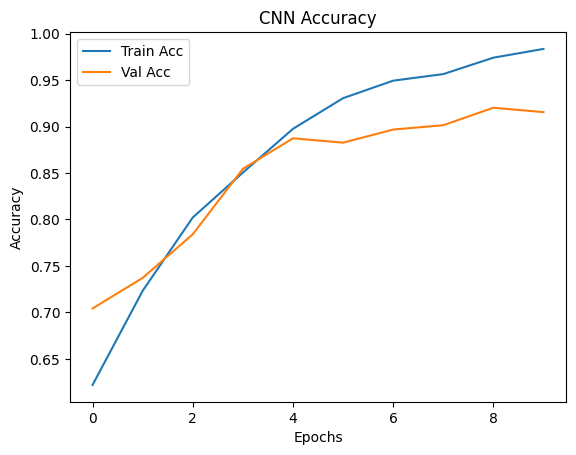

In [15]:
h = history["CNN"]

import matplotlib.pyplot as plt

plt.figure()

plt.plot(h.history['accuracy'], label='Train Acc')
plt.plot(h.history['val_accuracy'], label='Val Acc')

plt.title("CNN Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()

plt.show()


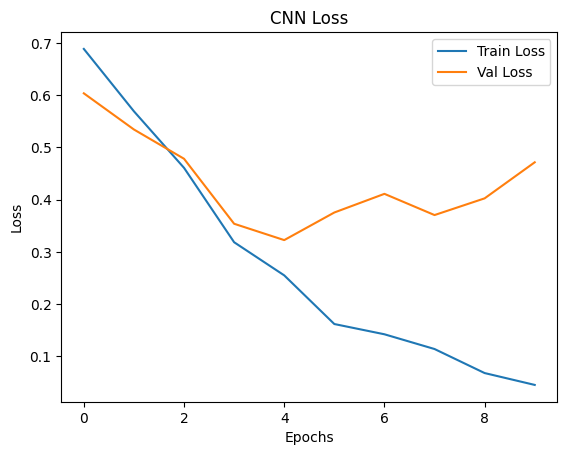

In [16]:
h = history["CNN"]

plt.figure()

plt.plot(h.history['loss'], label='Train Loss')
plt.plot(h.history['val_loss'], label='Val Loss')

plt.title("CNN Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()

plt.show()

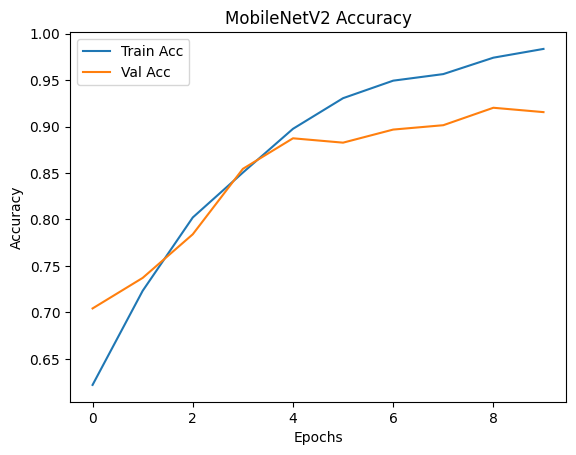

In [17]:
import matplotlib.pyplot as plt

plt.figure()

plt.plot(h.history['accuracy'], label='Train Acc')
plt.plot(h.history['val_accuracy'], label='Val Acc')

plt.title("MobileNetV2 Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()

plt.show()

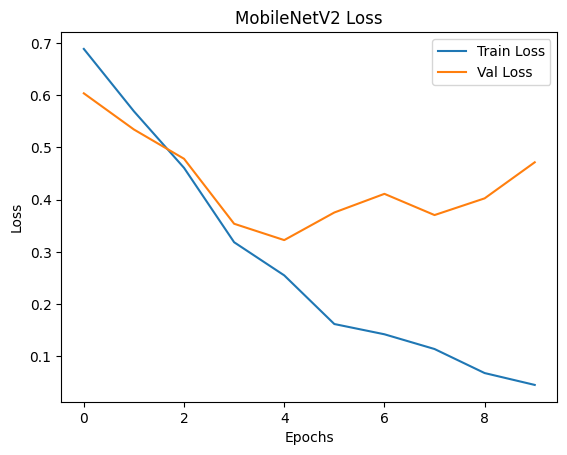

In [18]:
plt.figure()

plt.plot(h.history['loss'], label='Train Loss')
plt.plot(h.history['val_loss'], label='Val Loss')

plt.title("MobileNetV2 Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()

plt.show()

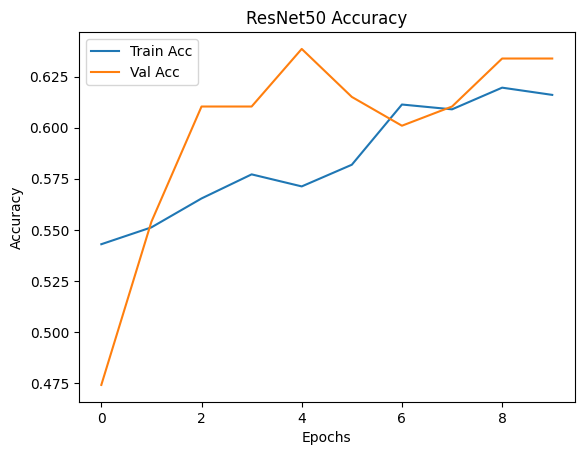

In [19]:
h = history["ResNet"]

plt.figure()

plt.plot(h.history['accuracy'], label='Train Acc')
plt.plot(h.history['val_accuracy'], label='Val Acc')

plt.title("ResNet50 Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()

plt.show()

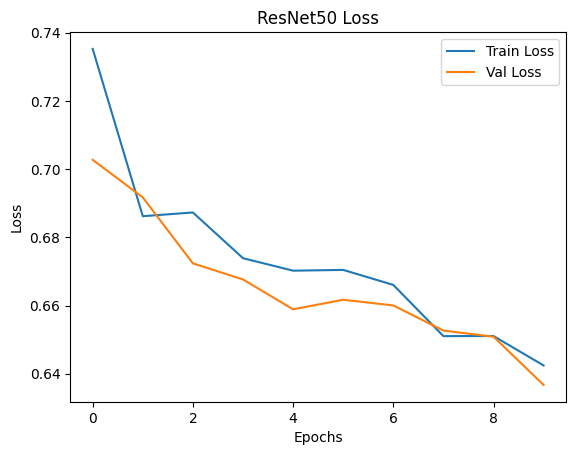

In [20]:
h = history["ResNet"]

plt.figure()

plt.plot(h.history['loss'], label='Train Loss')
plt.plot(h.history['val_loss'], label='Val Loss')

plt.title("ResNet50 Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()

plt.show()

In [21]:
from tensorflow.keras.preprocessing import image

def predict_image(img_path):
    img = image.load_img(img_path, target_size=(224,224))
    img_array = image.img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    model = keras.models.load_model("best_brain_tumor_model.h5")

    pred = model.predict(img_array, verbose=0)[0][0]

    if pred > 0.5:
        print("🧠 Tumor Detected (YES)")
    else:
        print("✅ No Tumor (NO)")

In [22]:
import os

# folders
no_path = "data/no"
yes_path = "data/yes"

# pick first 5 images from each
no_images = os.listdir(no_path)[:5]
yes_images = os.listdir(yes_path)[:5]

print("\n🔹 Predicting NO images:\n")
for img_name in no_images:
    img_path = os.path.join(no_path, img_name)
    print(f"Image: {img_name}")
    predict_image(img_path)
    print("-" * 30)


print("\n🔹 Predicting YES images:\n")
for img_name in yes_images:
    img_path = os.path.join(yes_path, img_name)
    print(f"Image: {img_name}")
    predict_image(img_path)
    print("-" * 30)


🔹 Predicting NO images:

Image: 95646643.jpg


✅ No Tumor (NO)
------------------------------
Image: 45474058.jpg
✅ No Tumor (NO)
------------------------------
Image: 95609197.jpg


✅ No Tumor (NO)
------------------------------
Image: 45490876.jpg


✅ No Tumor (NO)
------------------------------
Image: 45474266.jpg
✅ No Tumor (NO)
------------------------------

🔹 Predicting YES images:

Image: 45112843.jpg


🧠 Tumor Detected (YES)
------------------------------
Image: 43519310.jpg


🧠 Tumor Detected (YES)
------------------------------
Image: 95644256.jpg
🧠 Tumor Detected (YES)
------------------------------
Image: Y157.JPG


🧠 Tumor Detected (YES)
------------------------------
Image: 46932498.jpg
🧠 Tumor Detected (YES)
------------------------------
